In [1]:
from scipy.optimize import minimize as scipy_minimize
import matplotlib.pyplot as plt
import numpy as np
from functools import partial
from ket import *
from ket import ket_version

ket_version()

['Ket v0.9.3.2',
 'libket v0.6.0 [rustc 1.94.0 (4a4ef493e 2026-03-02) x86_64-unknown-linux-gnu]',
 'kbw v0.4.2 [rustc 1.94.0 (4a4ef493e 2026-03-02) x86_64-unknown-linux-gnu]']

# Auxillary Functions  

In [2]:
dim_grid = (20, 20)


def validar_ponto(ponto, dim_grid=dim_grid):
    """
    Dado um ponto, valida ele (len = 2 e não ultrapassa os limites da grid)

    Params
    Entrada:
    ponto: (int,int)
    dim_grid: [int,int]

    Saída:
    Bool: True se for válido
    """
    return len(ponto) == 2 and ponto[0] <= dim_grid[0] and ponto[1] <= dim_grid[1]


def validar_caminho(caminho, dim_grid=dim_grid):
    """
    Dado um caminho composto pelas coordenadas x e y de cada ponto do trajeto,
    verifica se corresponde a um caminho válido (sobre a regra de que cada ponto
    deve ser vizinho ao anterior e que não pode ultrapassar o tamanho da grid)

    Params
    Entrada:
    caminho: [(int,int)*]
    dim_grid: [int,int]

    Saída:
    Bool: True se for válido
    """
    for ponto in caminho:
        if not validar_ponto(ponto, dim_grid):
            return False

    for i in range(1, len(caminho)):
        # A estratégia utilizada é verificar se o valor absoluto da diferença dos pontos em cada eixo é igual ou menor que 1
        if not (
            abs(caminho[i][0] - caminho[i - 1][0]) <= 1
            and abs(caminho[i][1] - caminho[i - 1][1]) <= 1
        ):
            return False

    return True


class Veiculo:
    def __init__(self, start, goal):
        """
        Cria um veículo, se válido

        Params:
        Entrada:
        start: (int,int) -> Coordenadas de início
        goal: (int, int) -> Coordenadas de fim

        Saída:
        Veiculo
        """
        if not (validar_ponto(start) and validar_ponto(goal)):
            raise ValueError("Pontos de Start ou Goal inválidos")
        self.start = start
        self.goal = goal
        self.caminhos = []

    def add_caminho(self, caminho):
        """
        Cria um caminho, se válido

        Params:
        Entrada:
        caminho: [(int,int)*] -> Lista de coordenadas sequenciais do caminho
        """
        if (
            validar_caminho(caminho, dim_grid)
            and caminho[0] == self.start
            and caminho[-1] == self.goal
        ):
            self.caminhos.append(caminho)
        else:
            print("Caminho inválido")


def plotar_caminho(caminho, cor, linestyle, dim_grid=dim_grid, otimo=True):
    """
    Dado um caminho composto pelas coordenadas x e y de cada ponto do trajeto,
    plota o caminho na grid principal

    Params
    Entrada:
    caminho: [(int,int)*]
    dim_grid: [int,int]

    Saída:
    None
    """
    # Para plotar o caminho basta passar os valores de x e de y em ordem que
    # o pyplot faz sozinho
    x, y = [], []
    for ponto in caminho:
        x.append(ponto[0])
        y.append(ponto[1])

    # E daremos a opção de alterar cor e linestyle para diferenciação.
    # O "otimo" fará sentido quando tivermos alguma rota ótima, pois vamos querer
    # destacá-la
    plt.plot(x, y, cor, linestyle=linestyle, alpha=1 if otimo else 0.3)
    plt.draw()


def plotar_grid(veiculos, solucao=[]):
    """
    Dado uma lista de veículos, plota seus caminhos e destaca as posições inicial
    e final de cada um

    Params
    Entrada:
    veiculos: [Veiculo*]

    Saída:
    None
    """
    # Até 5 veículos sem repetir cor
    cores = {0: "b", 1: "r", 2: "g", 3: "k", 4: "m"}

    # Até 5 caminhos por veículo sem repetir linestyle
    linestyles = {0: "-", 1: "--", 2: ":", 3: "-.", 4: (0, (5, 10))}

    # Identificador de start ou end
    id_se = {0: "Start", 1: "Goal"}

    # Construção da grid
    plt.ion()
    plt.axis("scaled")
    plt.xlim(-1, dim_grid[0] + 1)
    plt.ylim(-1, dim_grid[1] + 1)
    plt.grid(True, linestyle=":")

    # Aqui para tirarmos as bordas da grid e régua de escala
    ax = plt.gca()
    ax.tick_params(
        axis="both",
        which="both",
        bottom=False,
        left=False,
        top=False,
        right=False,
        labelbottom=False,
        labelleft=False,
    )
    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.draw()

    n_veiculos = len(veiculos)
    n_caminhos = len(veiculos[0].caminhos)

    # Para todos os veículos...
    for i in range(n_veiculos):
        # Desenha os pontos de início e fim do veículo na grid
        start_end = [veiculos[i].start, veiculos[i].goal]
        for k in range(len(start_end)):
            x, y = start_end[k]
            plt.scatter(x, y, s=10, c=cores[i % 5])
            plt.text(x + 0.3, y + 0.3, id_se[k] + " V" + str(i), fontsize=8)
        # Plota cada caminho do veículo na grid
        for j in range(n_caminhos):
            # Se temos solução, podemos passá-la pra essa função, ela vai destacar as
            # rotas ótimas
            if np.any(solucao):
                otimo = (i * n_caminhos) + j == solucao[i]
            else:
                otimo = True
            plotar_caminho(
                veiculos[i].caminhos[j],
                cores[i % 5],
                linestyles[j % 5],
                dim_grid,
                otimo,
            )

    plt.ioff()
    plt.show()


def custo_caminho(caminho: list, alfa: int = 1) -> int:
    """
    Dado um caminho, retorna seu custo associado
    """
    return alfa * len(caminho)


def lista_pesos(veiculos: list) -> list:
    """
    Dado uma lista de veículos, retorna uma lista do custo de cada um de seus
    caminhos ordenados.
    """
    l = []
    for veiculo in veiculos:
        l.append(list(map(lambda caminho: custo_caminho(caminho), veiculo.caminhos)))
    return np.array(l)


def colisao(caminho_a, caminho_b, restricao=2):
    """
    Dados dois caminhos, identifica a possibilidade de colisão, definida por um
    ponto ser visitado por ambos caminhos em um intervalo curto (+-restricao)
    """
    # OBS: Restrição padrão atual está em 2, eu idealizei 1 mas o 2 torna as
    # chances de identificar colisão maiores, o que pode ser mais interessante

    # O(p)

    # Guarde os elementos de uma das listas como chaves de um dicionário, e seu
    # índice como valor
    dict_a = {}
    for a, ponto_a in enumerate(caminho_a):
        dict_a[ponto_a] = a

    # Agora verifica se o ponto da outra lista se encontra como chave do dicionário,
    # e se sim, verifica os índices
    for b, ponto_b in enumerate(caminho_b):
        if ponto_b in dict_a:
            if abs(b - dict_a[ponto_b]) < restricao:
                return True

    return False


def lista_colisoes(veiculos: list) -> list:
    """
    Dada uma lista de veículos, compara os caminhos de cada um com os caminhos dos
    demais e retorna uma lista de pares contendo colisões
    """
    # Espero muito que tenha uma solução mais eficiente que 4 fors aninhados
    # O(v²) + O(c²)
    colisoes = []
    # "Para cada veículo, verifique os veículos após o primeiro"
    for v, veiculo_v in enumerate(veiculos[:-1]):
        for u, veiculo_u in enumerate(veiculos[v + 1 :]):
            # "Para cada caminho de cada par de veículos, verifique se tem colisão"
            for cv, caminho_v in enumerate(veiculo_v.caminhos):
                for cu, caminho_u in enumerate(veiculo_u.caminhos):
                    if colisao(caminho_v, caminho_u):
                        # E adicione os índices (v,r) de ambos em par
                        colisoes.append(((v, cv), (v + 1 + u, cu)))
    return colisoes

# Instance

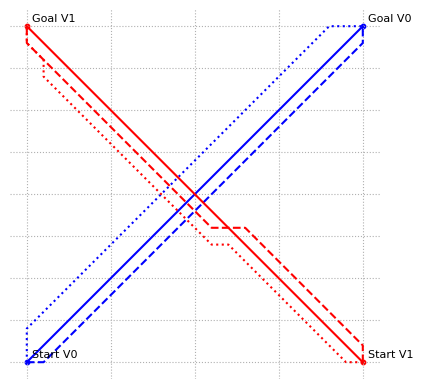

In [3]:
a = Veiculo((0, 0), (20, 20))
b = Veiculo((20, 0), (0, 20))
drones = [a, b]

# Aqui alguns exemplos de caminho utilizando list comprehensions

# Caminhos de A
a.add_caminho([(i, i) for i in range(21)])
a.add_caminho([(0, 0)] + [(i + 1, i) for i in range(20)] + [(20, 20)])
a.add_caminho([(0, 0), (0, 1)] + [(i, i + 2) for i in range(19)] + [(19, 20), (20, 20)])
# Caminhos de B
b.add_caminho([(20 - i, i) for i in range(21)])
# b.add_caminho([((40-i)//2,i//2) for i in range(41)]) # apagando a rota, suspeito que ela seja um outlier que atrapalha o resto
b.add_caminho(
    [(20, 0)]
    + [(20 - i, i + 1) for i in range(7)]
    + [(13, 8), (12, 8)]
    + [(20 - i, i - 1) for i in range(9, 21)]
    + [(0, 20)]
)
b.add_caminho(
    [(20, 0)]
    + [(19 - i, i) for i in range(8)]
    + [(11, 7)]
    + [(10 - i, 8 + i) for i in range(10)]
    + [(1, 18), (0, 19), (0, 20)]
)  # estou colocando essa no lugar

plotar_grid([a, b])

# $H_C$

In [4]:
def cost(
    qubits: Quant,
    drones: list,
    penalty: float = 1.5,
    one_route_constraint: bool = True,
) -> Hamiltonian:
    distance = lista_pesos(drones)
    penalty = np.max(distance) * penalty
    collision = lista_colisoes(drones)

    n_drones = len(drones)
    n_routes = len(drones[0].caminhos)

    # Variáveis binárias
    x = [qubits[v * n_routes : (v + 1) * n_routes] for v in range(n_drones)]

    # Hamiltoniano de custo pré-constraints
    cost = sum(
        distance[v][c] * B(x[v][c]) for v in range(n_drones) for c in range(n_routes)
    )

    # Constraint 1: Apenas um caminho por veículo
    one_route = sum(
        (sum(B(x[v][c]) for c in range(n_routes)) - 1) ** 2 for v in range(n_drones)
    )

    # Constraint 2: Apenas rotas não conflitantes
    no_collision = sum(B(x[v1][c1]) * B(x[v2][c2]) for (v1, c1), (v2, c2) in collision)

    # Hamiltoniano de custo total
    if one_route_constraint:
        return cost + penalty * (one_route + no_collision)
    return cost + penalty * no_collision

## Classical Solution (Simulated Annealing)

In [5]:
best_state, best_energy = qulib.simulated_annealing(partial(cost, drones=drones), 2 * 3)
print(f"{best_state=:0{2*3}b}, {best_energy=}")

best_state=010100, best_energy=43.0


# $H_M$

In [6]:
def mixer(qubits: Quant, drones: list[Veiculo]) -> Hamiltonian:
    n_drones = len(drones)
    n_routes = len(drones[0].caminhos)
    x = [qubits[v * n_routes : (v + 1) * n_routes] for v in range(n_drones)]
    return sum(qulib.ham.xy_mixer(x[v]) for v in range(n_drones))

# Initial State

In [7]:
def init(qubits: Quant, drones: list[Veiculo]):
    n_drones = len(drones)
    n_routes = len(drones[0].caminhos)
    for v in range(n_drones):
        qulib.prepare.w(qubits[v * n_routes : (v + 1) * n_routes])

# QAOA Anzats

In [8]:
from typing import Callable


def objective(
    initial_state,
    cost_h,
    mixer_h,
    num_qubits: int,
    parameters: list[float],
    make_process,
    final=False,
    shots=100,
):
    p = make_process()
    q = p.alloc(num_qubits)

    initial_state(q)

    l = (len(parameters) - 1) // 2
    gamma = parameters[:l]
    beta = parameters[l:]

    evolve(beta[0] * mixer_h(q))
    beta = beta[1:]

    for g, b in zip(gamma, beta):
        evolve(g * cost_h(q))
        evolve(b * mixer_h(q))

    if final:
        return sample(q, shots)
    return exp_value(cost_h(q)).get()


def callback(*, intermediate_result):
    print(
        f"it: {intermediate_result.nfev}, Energy: {intermediate_result.fun}", end="\r"
    )


def minimize(
    initial_state,
    cost_h,
    mixer_h,
    num_qubits: int,
    num_layers: int | None = None,
    parameters: list[float] | None = None,
    maxiter: int = 100,
    make_process: Callable[[], Process] | None = None,
    shots=100_000,
):
    if parameters is None:
        dt = 0.5
        parameters = [i / num_layers * dt for i in range(1, num_layers + 1)] + [
            (1 - i / num_layers) * dt for i in range(1, num_layers + 1)
        ]
    else:
        num_layers = (len(parameters) - 1) // 2

    def default_make_process():
        return Process(
            execution="batch",
            simulator="sparse",
            num_qubits=num_qubits,
        )

    if make_process is None:
        make_process = default_make_process

    res = scipy_minimize(
        partial(
            objective,
            initial_state,
            cost_h,
            mixer_h,
            num_qubits,
            make_process=make_process,
        ),
        parameters,
        method="COBYLA",
        options={"maxiter": maxiter},
        callback=callback,
    )

    return res, objective(
        initial_state,
        cost_h,
        mixer_h,
        num_qubits,
        res.x,
        make_process,
        True,
        shots,
    )

# Result

In [9]:
res_anzats, result_anzats = minimize(
    initial_state=partial(init, drones=drones),
    cost_h=partial(cost, drones=drones, one_route_constraint=False),
    mixer_h=partial(mixer, drones=drones),
    num_qubits=2 * 3,
    num_layers=7,
    maxiter=1_000,
)

In [10]:
print(res_anzats)
result_anzats.histogram("bin", width=1000, height=500).write_image("qaoa_anzats.pdf")
result_anzats.histogram("bin")

 message: Return from COBYLA because the objective function has been evaluated MAXFUN times.
 success: False
  status: 3
     fun: 44.618225411287455
       x: [ 8.817e-02  1.438e-01 ...  1.091e+00 -6.251e-03]
    nfev: 1000
   maxcv: 0.0


In [11]:
def print_result(result, best_state):
    print("|State | Count| Energy|")
    for state, count in sorted(
        result.get().items(), key=lambda kv: kv[1], reverse=True
    ):
        energy = qulib.energy(partial(cost, drones=drones), state, num_qubits=2 * 3)
        line = f"|{state:0{2*3}b}|{count:>6}|{energy:7.2f}|"
        if state == best_state:
            line = f"\033[92m{line}\033[0m"
        print(line)


print_result(result_anzats, best_state)

|State | Count| Energy|
|010100| 34291|  43.00|
|001010| 20847|  46.00|
|001001| 19536|  46.00|
|100001| 12964|  44.00|
|100010|  7484|  44.00|
|010001|  4574|  45.00|
|001100|   155|  78.50|
|100100|   123|  76.50|
|010010|    26|  79.50|


## QAOA

In [12]:
res_qaoa, result_qaoa = minimize(
    initial_state=H,
    cost_h=partial(cost, drones=drones),
    mixer_h=qulib.ham.x_mixer,
    num_qubits=2 * 3,
    num_layers=7,
    maxiter=1_000,
)

In [13]:
print(res_qaoa)
result_qaoa.histogram("bin", width=1000, height=500).write_image("qaoa.pdf")
result_qaoa.histogram("bin")

 message: Return from COBYLA because the objective function has been evaluated MAXFUN times.
 success: False
  status: 3
     fun: 79.34640097580663
       x: [ 1.655e-01  5.628e-01 ...  3.809e-01  3.341e-01]
    nfev: 1000
   maxcv: 0.0


In [14]:
print_result(result_qaoa, best_state)

|State | Count| Energy|
|000000| 29513|  69.00|
|100100| 14982|  76.50|
|000100| 11091|  55.50|
|001100|  6157|  78.50|
|100000|  4004|  55.50|
|010000|  3997|  56.50|
|010100|  3906|  43.00|
|000010|  2892|  57.50|
|001000|  1979|  57.50|
|000011|  1931| 115.00|
|110110|  1902| 225.00|
|100101|  1866| 134.00|
|000001|  1465|  57.50|
|100010|  1383|  44.00|
|000110|  1362| 113.00|
|011100|  1194| 135.00|
|110010|   913| 135.00|
|110100|   767| 133.00|
|010010|   738|  79.50|
|100001|   639|  44.00|
|001010|   571|  46.00|
|101000|   569| 113.00|
|100110|   472| 134.00|
|001001|   472|  46.00|
|010110|   369| 135.00|
|100011|   341| 101.50|
|110101|   338| 190.50|
|101100|   321| 168.50|
|010001|   311|  45.00|
|111000|   253| 238.50|
|001110|   250| 136.00|
|010101|   240| 100.50|
|001011|   239| 103.50|
|011010|   228| 137.00|
|001101|   215| 136.00|
|110111|   214| 351.50|
|000111|   179| 239.50|
|011000|   174| 114.00|
|111100|   174| 294.00|
|101010|   167| 101.50|
|010011|   125| 

# IBM

In [15]:
from ket.ibm import IBMDevice
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeBrisbane as Provider


def ibm_precess():
    backend = Provider()
    simulator = AerSimulator.from_backend(backend)
    device = IBMDevice(simulator)
    return Process(device)


res_ibm_anzats, result_ibm_anzats = minimize(
    initial_state=partial(init, drones=drones),
    cost_h=partial(cost, drones=drones, one_route_constraint=False),
    mixer_h=partial(mixer, drones=drones),
    make_process=ibm_precess,
    num_qubits=2 * 3,
    num_layers=7,
    maxiter=1_000,
)

/home/evandro/workspace/drone2/.venv/lib/python3.14/site-packages/samplomatic/__init__.py:20: UserWarning: 
You have imported samplomatic==0.18.0 which is in 
beta development. Please expect breaking changes between 
minor versions and pin your dependencies accordingly.
  _warn_once_per_version(


In [16]:
print(res_ibm_anzats)
result_ibm_anzats.histogram("bin", width=1000, height=500).write_image(
    "qaoa_anzats_ibm_noise.pdf"
)
result_ibm_anzats.histogram("bin")

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: 69.0419921875
       x: [ 6.928e-02  1.235e-01 ...  1.478e-02  1.080e+00]
    nfev: 115
   maxcv: 0.0


In [17]:
print_result(result_ibm_anzats, best_state)

|State | Count| Energy|
|100001|  6577|  44.00|
|100010|  5529|  44.00|
|001010|  5504|  46.00|
|000010|  3394|  57.50|
|000001|  3271|  57.50|
|010010|  3114|  79.50|
|001001|  3094|  46.00|
|101010|  3055| 101.50|
|001100|  3034|  78.50|
|110010|  2833| 135.00|
|101001|  2775| 101.50|
|100100|  2282|  76.50|
|010001|  2254|  45.00|
|000100|  2230|  55.50|
|011010|  2152| 137.00|
|100000|  2044|  55.50|
|010100|  2035|  43.00|
|110001|  1964| 100.50|
|111010|  1826| 261.50|
|101100|  1796| 168.50|
|011001|  1789| 102.50|
|100011|  1629| 101.50|
|011100|  1527| 135.00|
|110100|  1525| 133.00|
|001000|  1480|  57.50|
|111001|  1432| 227.00|
|100110|  1409| 134.00|
|000000|  1370|  69.00|
|001011|  1304| 103.50|
|001110|  1236| 136.00|
|010000|  1222|  56.50|
|100101|  1218| 134.00|
|001101|  1110| 136.00|
|111100|  1101| 294.00|
|101000|  1052| 113.00|
|000011|   990| 115.00|
|110000|   987| 112.00|
|000110|   957| 113.00|
|010110|   936| 135.00|
|000101|   891| 113.00|
|011000|   855| 

## QAOA

In [18]:
from ket.ibm import IBMDevice
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime.fake_provider import FakeBrisbane as Provider


def ibm_precess():
    backend = Provider()
    simulator = AerSimulator.from_backend(backend)
    device = IBMDevice(simulator)
    return Process(device)


res_ibm_qaoa, result_ibm_qaoa = minimize(
    initial_state=H,
    cost_h=partial(cost, drones=drones),
    mixer_h=qulib.ham.x_mixer,
    make_process=ibm_precess,
    num_qubits=2 * 3,
    num_layers=7,
    maxiter=1_000,
)

In [19]:
print(res_ibm_qaoa)
result_ibm_qaoa.histogram("bin", width=1000, height=500).write_image(
    "qaoa_ibm_noise.pdf"
)
result_ibm_qaoa.histogram("bin")

 message: Return from COBYLA because the trust region radius reaches its lower bound.
 success: True
  status: 0
     fun: 118.34814453125
       x: [ 1.284e+00  1.479e-01 ... -4.479e-01 -2.698e-02]
    nfev: 106
   maxcv: 0.0


In [20]:
print_result(result_ibm_qaoa, best_state)

|State | Count| Energy|
|100100|  7310|  76.50|
|110100|  7028| 133.00|
|010100|  4783|  43.00|
|000100|  3805|  55.50|
|101100|  3669| 168.50|
|110000|  3338| 112.00|
|010000|  3205|  56.50|
|111100|  3071| 294.00|
|100000|  2935|  55.50|
|001100|  2643|  78.50|
|100110|  2430| 134.00|
|000000|  2261|  69.00|
|011100|  2139| 135.00|
|100010|  2044|  44.00|
|110001|  2000| 100.50|
|110110|  1909| 225.00|
|010001|  1908|  45.00|
|101000|  1752| 113.00|
|001000|  1686|  57.50|
|000010|  1672|  57.50|
|100001|  1667|  44.00|
|110010|  1623| 135.00|
|110101|  1534| 190.50|
|100101|  1527| 134.00|
|010010|  1442|  79.50|
|011000|  1440| 114.00|
|000001|  1437|  57.50|
|000110|  1415| 113.00|
|111000|  1408| 238.50|
|010110|  1312| 135.00|
|010101|  1196| 100.50|
|001010|  1160|  46.00|
|101010|  1108| 101.50|
|101110|  1106| 226.00|
|001001|  1044|  46.00|
|101001|  1002| 101.50|
|001110|   934| 136.00|
|000101|   892| 113.00|
|011001|   869| 102.50|
|100111|   858| 260.50|
|111110|   854| 